In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/input/all_data.csv")

In [4]:
df.head()

,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,wow,...,white,asian,latino,other_race_or_ethnicity,physical_disability,intellectual_or_learning_disability,psychiatric_or_mental_illness,other_disability,identity_annotator_count,toxicity_annotator_count
0,1083994,He got his money... now he lies in wait till a...,train,2017-03-06 15:21:53.675241+00,21,NaN,317120,approved,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,67
1,650904,Mad dog will surely put the liberals in mental...,train,2016-12-02 16:44:21.329535+00,21,NaN,154086,approved,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,76
2,5902188,And Trump continues his lifelong cowardice by ...,train,2017-09-05 19:05:32.341360+00,55,NaN,374342,approved,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,63
3,7084460,"""while arresting a man for resisting arrest"".\...",test,2016-11-01 16:53:33.561631+00,13,NaN,149218,approved,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,76
4,5410943,Tucker and Paul are both total bad ass mofo's.,train,2017-06-14 05:08:21.997315+00,21,NaN,344096,approved,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,80


In [5]:
df.columns

Index(['id', 'comment_text', 'split', 'created_date', 'publication_id',
       'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes',
       'disagree', 'toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit',
       'identity_attack', 'insult', 'threat', 'male', 'female', 'transgender',
       'other_gender', 'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual',
       'other_sexual_orientation', 'christian', 'jewish', 'muslim', 'hindu',
       'buddhist', 'atheist', 'other_religion', 'black', 'white', 'asian',
       'latino', 'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count'],
      dtype='str')

In [6]:
df["toxicity"].value_counts()

toxicity
0.000000    1401762
0.166667     153425
0.200000     118991
0.300000      65266
0.400000      55377
             ...   
0.897840          1
0.985654          1
0.647619          1
0.976073          1
0.897351          1
Name: count, Length: 3063, dtype: int64

In [7]:
len(df[df["toxicity"]>=0.5])/len(df)

0.07991033830186905

In [8]:
df["severe_toxicity"].value_counts()

severe_toxicity
0.000000    1883681
0.100000      37971
0.166667       7660
0.200000       6260
0.014286       1958
             ...   
0.057210          1
0.327426          1
0.384940          1
0.195364          1
0.041026          1
Name: count, Length: 1568, dtype: int64

In [9]:
len(df[df["severe_toxicity"]>=0.5])/len(df)

6.501573380758144e-06

In [10]:
# Select the columns, check if they are >= 0.5, see if 'any' match per row, and calculate the mean (percentage)
cols = ['obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']
len(df[df[cols].ge(0.5).any(axis=1)])/len(df)


0.06991742001564379

In [11]:
SUBTYPE_COLS = ['obscene', 'sexual_explicit',
                'identity_attack', 'insult', 'threat']
THRESHOLD = 0.5
# ─────────────────────────────────────────────
# STEP 1: Define sets using row index sets
# ─────────────────────────────────────────────

# Set A: all rows where toxicity >= 0.5  (the "toxic" set)
A = set(df.index[df['toxicity'] >= THRESHOLD])

# Set B: all rows where at least one subtype >= 0.5  (the "subtype-labeled" set)
B = set(df.index[df[SUBTYPE_COLS].ge(THRESHOLD).any(axis=1)])

# Universe: all row indices
U = set(df.index)

print("=" * 55)
print("  SET THEORY VERIFICATION")
print("=" * 55)
print(f"\n  |U|  = {len(U):>10,}   (entire dataset)")
print(f"  |A|  = {len(A):>10,}   (toxic >= 0.5)")
print(f"  |B|  = {len(B):>10,}   (any subtype >= 0.5)")

# ─────────────────────────────────────────────
# STEP 2: The four regions of a Venn diagram
# ─────────────────────────────────────────────
#
#   ┌─────────────────────────────────┐
#   │  U                              │
#   │   ┌───────┐   ┌───────┐        │
#   │   │  A\B  │ ∩ │  B\A  │        │
#   │   │       │A∩B│       │        │
#   │   └───────┘   └───────┘        │
#   │         (A∪B)ᶜ                 │
#   └─────────────────────────────────┘

A_and_B   = A & B          # toxic AND has subtype label
A_not_B   = A - B          # toxic BUT no subtype >= 0.5  ← the gap we found
B_not_A   = B - A          # has subtype label BUT not toxic (false positive subtypes?)
neither   = U - (A | B)    # neither toxic nor subtype-labeled

print("\n─── Venn Diagram Regions ───────────────────────────")
print(f"  A ∩ B  (toxic AND subtype labeled)  : {len(A_and_B):>10,}  ({len(A_and_B)/len(U)*100:.2f}%)")
print(f"  A \\ B  (toxic, NO subtype >= 0.5)   : {len(A_not_B):>10,}  ({len(A_not_B)/len(U)*100:.2f}%)")
print(f"  B \\ A  (subtype labeled, NOT toxic)  : {len(B_not_A):>10,}  ({len(B_not_A)/len(U)*100:.2f}%)")
print(f"  (A∪B)ᶜ (neither)                    : {len(neither):>10,}  ({len(neither)/len(U)*100:.2f}%)")

# ─────────────────────────────────────────────
# STEP 3: Verify the partition sums to |U|
# ─────────────────────────────────────────────
total = len(A_and_B) + len(A_not_B) + len(B_not_A) + len(neither)
print(f"\n─── Partition Check ────────────────────────────────")
print(f"  Sum of all 4 regions : {total:>10,}")
print(f"  |U|                  : {len(U):>10,}")
print(f"  ✓ Partition is valid : {total == len(U)}")

# ─────────────────────────────────────────────
# STEP 4: Verify set laws
# ─────────────────────────────────────────────
print(f"\n─── Set Law Checks ─────────────────────────────────")

# Inclusion-Exclusion: |A ∪ B| = |A| + |B| - |A ∩ B|
A_union_B = A | B
lhs = len(A_union_B)
rhs = len(A) + len(B) - len(A_and_B)
print(f"  Inclusion-Exclusion  |A∪B| = |A|+|B|-|A∩B|")
print(f"    LHS |A∪B|          = {lhs:>10,}")
print(f"    RHS |A|+|B|-|A∩B|  = {rhs:>10,}")
print(f"    ✓ Holds             : {lhs == rhs}")

# Complement: |A| = |A∩B| + |A\B|
lhs2 = len(A)
rhs2 = len(A_and_B) + len(A_not_B)
print(f"\n  Complement  |A| = |A∩B| + |A\\B|")
print(f"    LHS |A|         = {lhs2:>10,}")
print(f"    RHS             = {rhs2:>10,}")
print(f"    ✓ Holds         : {lhs2 == rhs2}")

# Complement: |B| = |A∩B| + |B\A|
lhs3 = len(B)
rhs3 = len(A_and_B) + len(B_not_A)
print(f"\n  Complement  |B| = |A∩B| + |B\\A|")
print(f"    LHS |B|         = {lhs3:>10,}")
print(f"    RHS             = {rhs3:>10,}")
print(f"    ✓ Holds         : {lhs3 == rhs3}")

# ─────────────────────────────────────────────
# STEP 5: Drill into A\B — the gap we found
# ─────────────────────────────────────────────
print(f"\n─── Deep Dive: A \\ B  (toxic but no subtype >= 0.5) ─")
gap_df = df.loc[list(A_not_B)]

# Are any subtypes > 0 (annotated but weak)?
has_any_signal = gap_df[SUBTYPE_COLS].gt(0).any(axis=1)
print(f"  Of {len(gap_df):,} rows in A\\B:")
print(f"    Have at least one subtype > 0 (weak signal) : {has_any_signal.sum():>8,}  ({has_any_signal.mean()*100:.1f}%)")
print(f"    All subtypes exactly 0 (truly unlabeled)    : {(~has_any_signal).sum():>8,}  ({(~has_any_signal).mean()*100:.1f}%)")

# Annotator count breakdown
print(f"\n  Annotator count distribution in A\\B:")
print(gap_df['toxicity_annotator_count'].value_counts().sort_index().head(10).to_string())

# Max subtype value
max_sub = gap_df[SUBTYPE_COLS].max(axis=1)
print(f"\n  Max subtype value stats in A\\B:")
print(f"    mean   = {max_sub.mean():.4f}")
print(f"    median = {max_sub.median():.4f}")
print(f"    max    = {max_sub.max():.4f}  ← just below 0.5 threshold")

# ─────────────────────────────────────────────
# STEP 6: Drill into B\A — subtype labeled but not toxic
# ─────────────────────────────────────────────
print(f"\n─── Deep Dive: B \\ A  (subtype labeled but NOT toxic) ─")
false_pos = df.loc[list(B_not_A)]
print(f"  Count: {len(false_pos):,}")
print(f"  Toxicity score distribution:")
print(false_pos['toxicity'].describe().to_string())
print(f"\n  Sample comments:")
for _, row in false_pos[['comment_text', 'toxicity'] + SUBTYPE_COLS].head(4).iterrows():
    active = [c for c in SUBTYPE_COLS if row[c] >= 0.5]
    print(f"    toxicity={row['toxicity']:.3f} | subtypes={active}")
    print(f"    text: {str(row['comment_text'])[:100]}")
    print()

# ─────────────────────────────────────────────
# STEP 7: Final summary
# ─────────────────────────────────────────────
print("=" * 55)
print("  FINAL SUMMARY")
print("=" * 55)
print(f"""
  Your original query (any subtype >= 0.5) gave 6.99%.
  The actual toxic rate is 7.99%.
  The gap is exactly |A \\ B| = {len(A_not_B):,} rows ({len(A_not_B)/len(U)*100:.2f}%).

  Set theory confirms:
    |A| = |A∩B| + |A\\B|
    {len(A):,} = {len(A_and_B):,} + {len(A_not_B):,}  ✓

  Root cause: {has_any_signal.sum():,} of these rows DO have subtype
  signal (> 0) but annotators split votes across subtypes,
  so no single subtype crossed the 0.5 threshold.
  78% of them have exactly 10 annotators — at 10 annotators,
  you need 5/10 to agree on one subtype to hit 0.5.
  If 4 say insult and 4 say obscene → both stay at 0.4.
""")


  SET THEORY VERIFICATION

  |U|  =  1,999,516   (entire dataset)
  |A|  =    159,782   (toxic >= 0.5)
  |B|  =    139,801   (any subtype >= 0.5)

─── Venn Diagram Regions ───────────────────────────
  A ∩ B  (toxic AND subtype labeled)  :    135,148  (6.76%)
  A \ B  (toxic, NO subtype >= 0.5)   :     24,634  (1.23%)
  B \ A  (subtype labeled, NOT toxic)  :      4,653  (0.23%)
  (A∪B)ᶜ (neither)                    :  1,835,081  (91.78%)

─── Partition Check ────────────────────────────────
  Sum of all 4 regions :  1,999,516
  |U|                  :  1,999,516
  ✓ Partition is valid : True

─── Set Law Checks ─────────────────────────────────
  Inclusion-Exclusion  |A∪B| = |A|+|B|-|A∩B|
    LHS |A∪B|          =    164,435
    RHS |A|+|B|-|A∩B|  =    164,435
    ✓ Holds             : True

  Complement  |A| = |A∩B| + |A\B|
    LHS |A|         =    159,782
    RHS             =    159,782
    ✓ Holds         : True

  Complement  |B| = |A∩B| + |B\A|
    LHS |B|         =    139,801
    

In [12]:
toxic=df[df['toxicity']>=0.5]

In [13]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set general plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

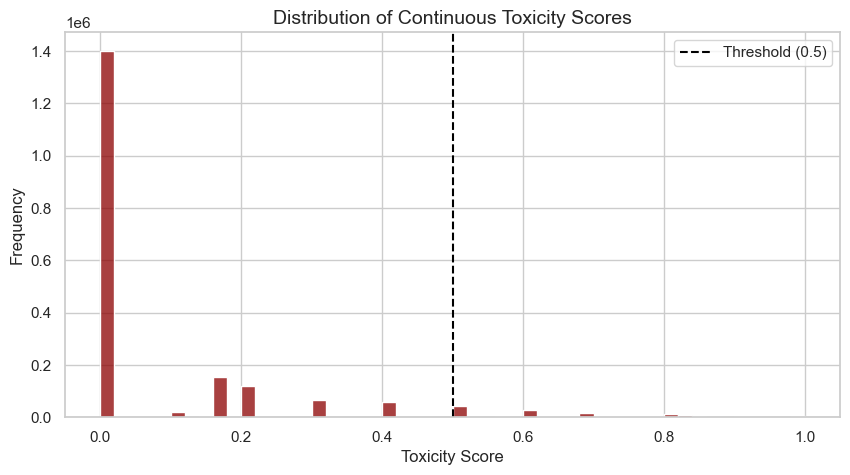

C:\Users\priya\AppData\Local\Temp\ipykernel_16888\3466874239.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_toxic', palette=['#4C72B0', '#C44E52'])


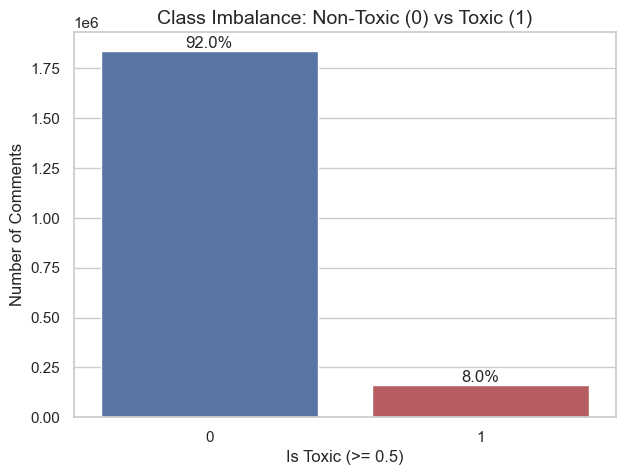

In [14]:
# %%
# 1. Histogram of the continuous toxicity scores
plt.figure(figsize=(10, 5))
sns.histplot(df['toxicity'], bins=50, kde=False, color='darkred')
plt.title('Distribution of Continuous Toxicity Scores', fontsize=14)
plt.xlabel('Toxicity Score')
plt.ylabel('Frequency')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
plt.legend()
plt.show()

# %%
# 2. Countplot of Binary Toxicity (Toxic vs. Non-Toxic)
df['is_toxic'] = (df['toxicity'] >= 0.5).astype(int)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='is_toxic', palette=['#4C72B0', '#C44E52'])
plt.title('Class Imbalance: Non-Toxic (0) vs Toxic (1)', fontsize=14)
plt.xlabel('Is Toxic (>= 0.5)')
plt.ylabel('Number of Comments')

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

C:\Users\priya\AppData\Local\Temp\ipykernel_16888\578310972.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subtype_percentages.values, y=subtype_percentages.index, palette='magma')


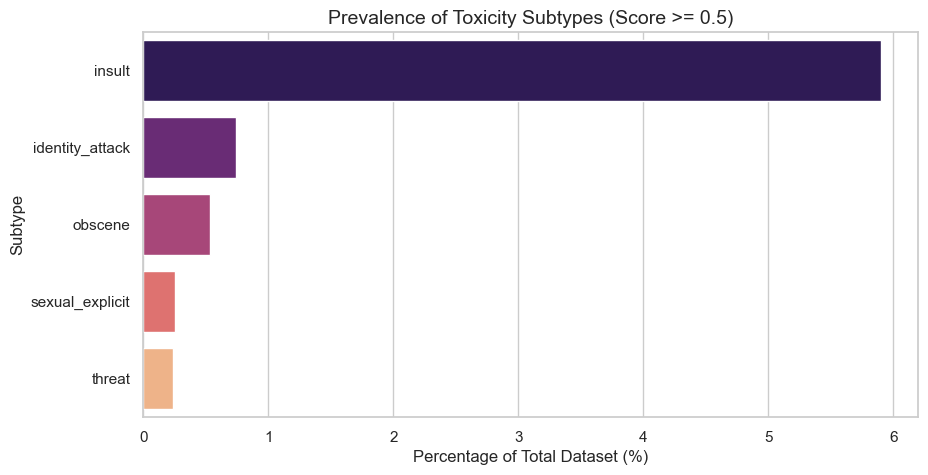

In [15]:
# %%
# Calculate the percentage of each subtype being >= 0.5
SUBTYPE_COLS = ['obscene', 'sexual_explicit', 'identity_attack', 'insult', 'threat']

subtype_counts = (df[SUBTYPE_COLS] >= 0.5).sum().sort_values(ascending=False)
subtype_percentages = (subtype_counts / len(df)) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=subtype_percentages.values, y=subtype_percentages.index, palette='magma')
plt.title('Prevalence of Toxicity Subtypes (Score >= 0.5)', fontsize=14)
plt.xlabel('Percentage of Total Dataset (%)')
plt.ylabel('Subtype')
plt.show()

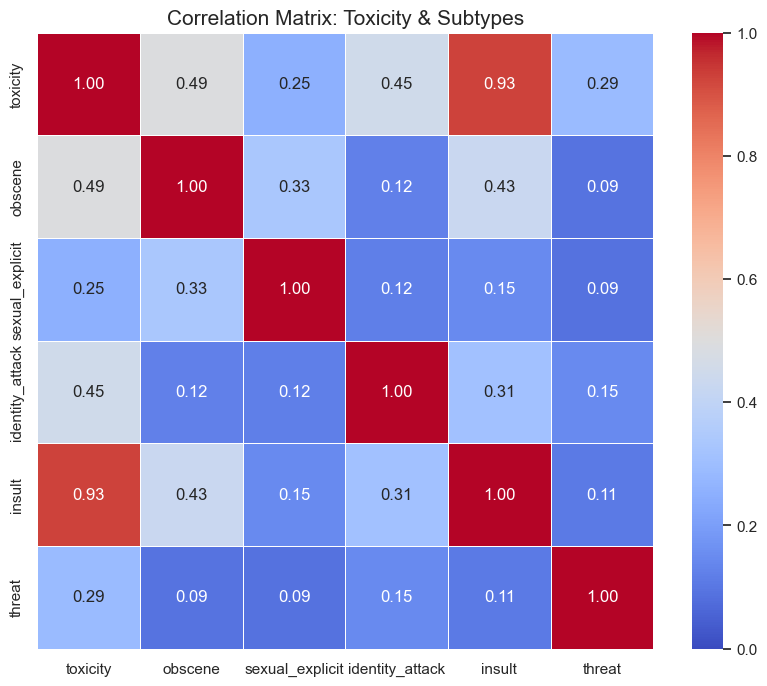

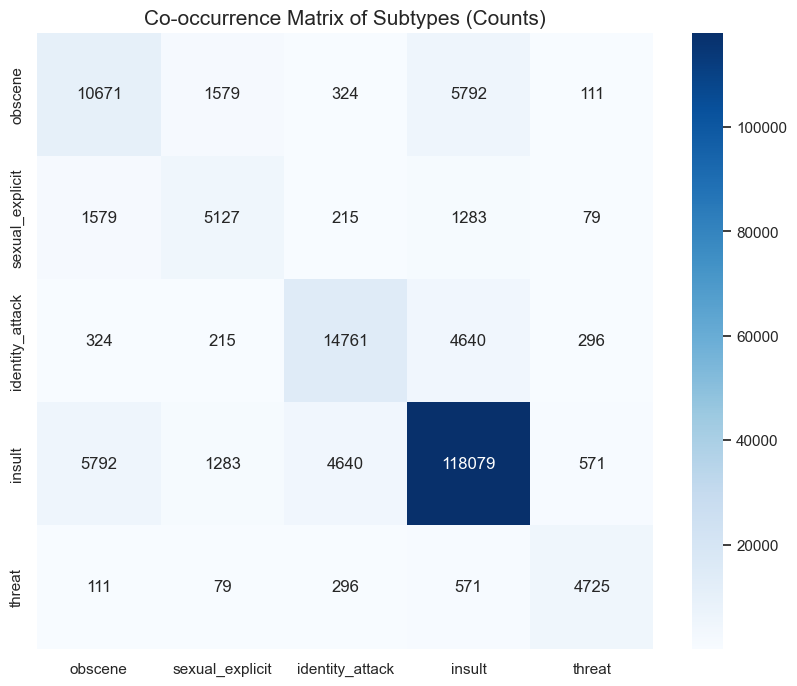

In [16]:
# %%
# Correlation Heatmap for Toxicity and Subtypes
corr_cols = ['toxicity'] + SUBTYPE_COLS
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1, 
            square=True, linewidths=.5)
plt.title('Correlation Matrix: Toxicity & Subtypes', fontsize=15)
plt.show()

# %%
# Subtype Co-occurrence Matrix (How often do two subtypes appear together >= 0.5)
binary_subtypes = (df[SUBTYPE_COLS] >= 0.5).astype(int)
co_occurrence = binary_subtypes.T.dot(binary_subtypes)

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, cmap='Blues', fmt="d", square=True)
plt.title('Co-occurrence Matrix of Subtypes (Counts)', fontsize=15)
plt.show()

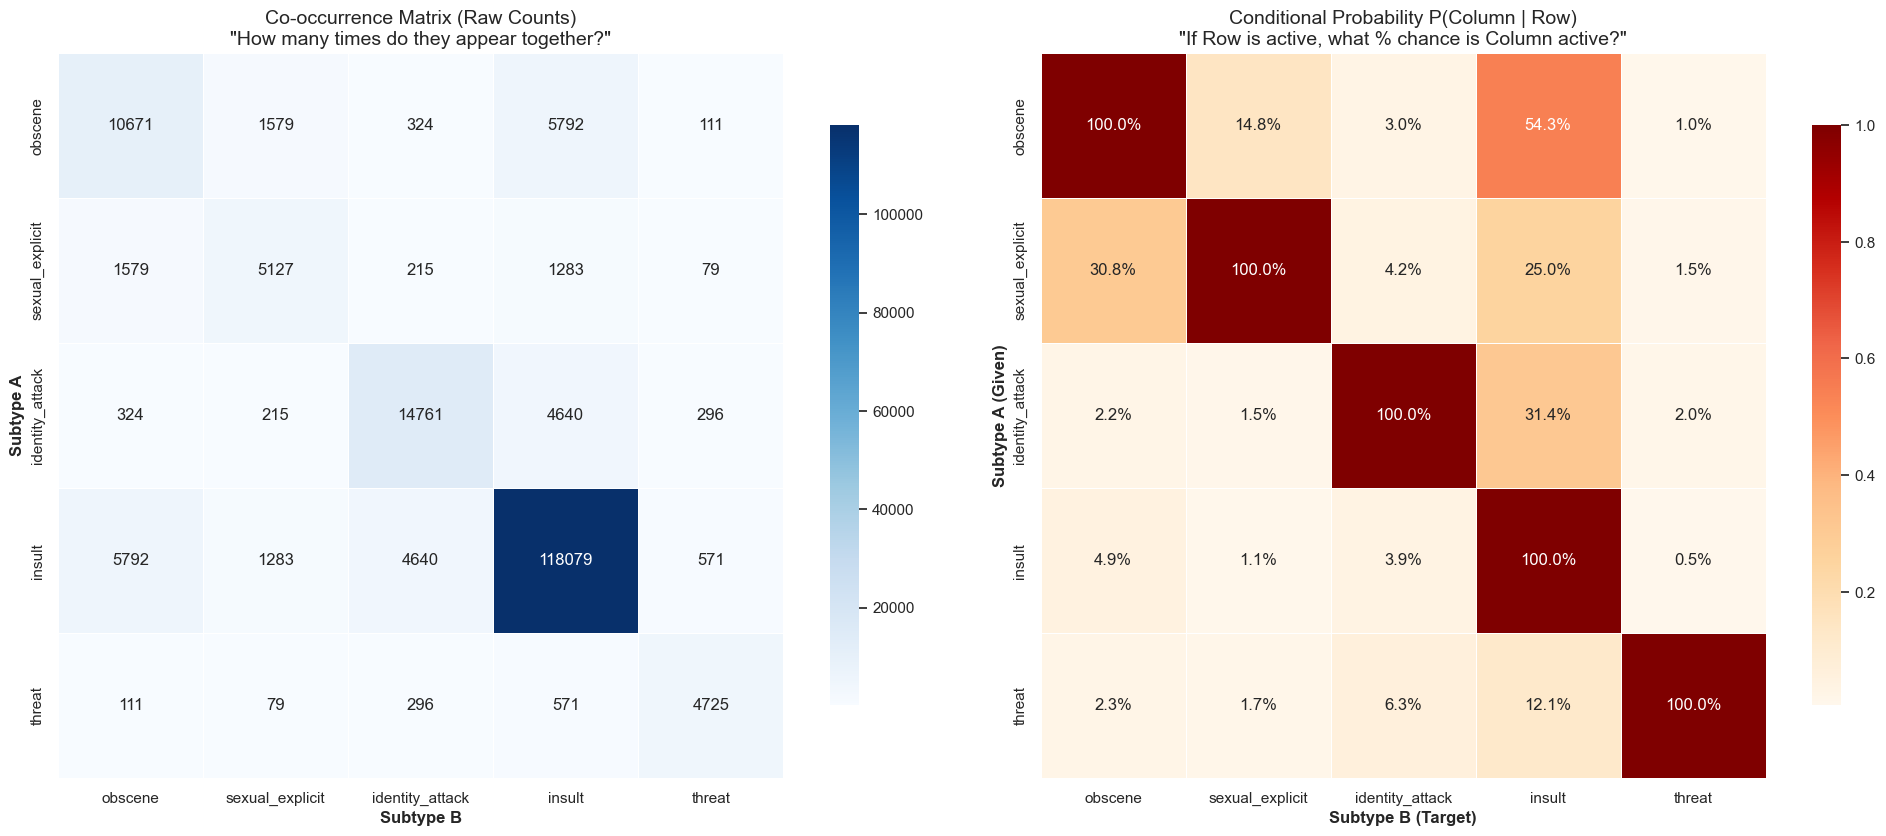

Top 3 Strongest Subtype Relationships (Conditional):
 - If 'obscene', there is a 54.3% chance of 'insult'
 - If 'identity_attack', there is a 31.4% chance of 'insult'
 - If 'sexual_explicit', there is a 30.8% chance of 'obscene'


In [17]:
# %%
# ─────────────────────────────────────────────
# ENHANCED CO-OCCURRENCE ANALYSIS
# ─────────────────────────────────────────────
import numpy as np

# Create binary mask for subtypes >= 0.5
binary_subtypes = (df[SUBTYPE_COLS] >= 0.5).astype(int)

# 1. Absolute Co-occurrence (Raw Counts)
co_occurrence_counts = binary_subtypes.T.dot(binary_subtypes)

# 2. Normalized Co-occurrence (Conditional Probability)
# Formula: P(Column | Row) = Count(Row & Col) / Count(Row)
# This divides each row by the total occurrences of that specific subtype
diagonal_counts = np.diag(co_occurrence_counts)
co_occurrence_prob = co_occurrence_counts.divide(diagonal_counts, axis=0)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Raw Counts
sns.heatmap(co_occurrence_counts, annot=True, cmap='Blues', fmt="d", 
            square=True, ax=axes[0], cbar_kws={"shrink": 0.8}, linewidths=0.5)
axes[0].set_title('Co-occurrence Matrix (Raw Counts)\n"How many times do they appear together?"', fontsize=14)
axes[0].set_xlabel('Subtype B', fontweight='bold')
axes[0].set_ylabel('Subtype A', fontweight='bold')

# Plot 2: Conditional Probabilities
sns.heatmap(co_occurrence_prob, annot=True, cmap='OrRd', fmt=".1%", 
            square=True, ax=axes[1], cbar_kws={"shrink": 0.8}, linewidths=0.5)
axes[1].set_title('Conditional Probability P(Column | Row)\n"If Row is active, what % chance is Column active?"', fontsize=14)
axes[1].set_xlabel('Subtype B (Target)', fontweight='bold')
axes[1].set_ylabel('Subtype A (Given)', fontweight='bold')

plt.tight_layout()
plt.show()

# Optional: Print the strongest relationships
print("Top 3 Strongest Subtype Relationships (Conditional):")
# Flatten the matrix, remove self-correlations (100%), and sort
stacked_probs = co_occurrence_prob.stack().reset_index()
stacked_probs.columns = ['Given_Subtype', 'Target_Subtype', 'Probability']
stacked_probs = stacked_probs[stacked_probs['Given_Subtype'] != stacked_probs['Target_Subtype']]
top_relations = stacked_probs.sort_values(by='Probability', ascending=False).head(3)

for idx, row in top_relations.iterrows():
    print(f" - If '{row['Given_Subtype']}', there is a {row['Probability']*100:.1f}% chance of '{row['Target_Subtype']}'")